[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/pachterlab/OP_2025/blob/main/analysis_scripts/Virus_12_DEseq.ipynb)

# Clone github repo

In [ ]:
!git clone https://github.com/pachterlab/OP_2025.git
%cd /content/OP_2025/

# Download Data

In [ ]:
!mkdir omics_adata
!wget -O omics_data/rat_RNA_meta.h5ad https://data.caltech.edu/records/j57wp-0pp06/files/rat_RNA_meta.h5ad?download=1
!wget -O omics_data/virus_post_qc.h5ad https://data.caltech.edu/records/j57wp-0pp06/files/virus_post_qc.h5ad?download=1


# Install Packages

In [ ]:
!pip install -qr ../requirements.txt 

In [2]:
# import packages

import sys
sys.path.append('analysis_scripts')

import time

# numbers
import numpy as np
import pandas as pd
import scipy

# sc
import anndata
import scanpy as sc

from pydeseq2.dds import DeseqDataSet
from pydeseq2.default_inference import DefaultInference
from pydeseq2.ds import DeseqStats
import statsmodels.stats.multitest

# plots
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text

from rat_friend import *


In [3]:
tissue_colors, _ = get_color_palettes()
color_dict = tissue_colors

# Load Data

## Load virus dataset

In [ ]:
virus_adata = anndata.read_h5ad("omics_data/virus_post_qc.h5ad")
virus_adata.obs['time'] = virus_adata.obs['time'].astype('int')
virus_adata = virus_adata[~virus_adata.obs['time'].isna()]
virus_adata = virus_adata[:,~virus_adata.var.contaminate].copy()
virus_adata.obs['lifetime'] = [8 if x == 0 else x for x in virus_adata.obs.time.values]
adata = virus_adata[virus_adata.obs['lifetime']==8]
adata

/var/folders/kj/wm2vrp3x04qgzq18l2rkrcxh0000gn/T/ipykernel_46159/3849816439.py:5: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  virus_adata.obs['lifetime'] = [8 if x == 0 else x for x in virus_adata.obs.time.values]


View of AnnData object with n_obs × n_vars = 353 × 30758
    obs: 'barcode', 'index', 'path', 'nac_path', 'mat_path', 'amb_path', 'time', 'sex', 'tissue', 'viallabel', 'calculated.variables.pct_body_fat_change', 'calculated.variables.pct_body_lean_change', 'calculated.variables.pct_body_fluid_change', 'calculated.variables.lactate_change_dueto_train', 'calculated.variables.vo2_max_change', 'calculated.variables.coll_time_train', 'calculated.variables.deathtime_after_train', 'calculated.variables.frozetime_after_train', 'pid', 'group', 'rank', 'nid', 'num_umi', 'old_tissue', 'lifetime'
    var: 'rep_ID', 'phylum', 'class', 'order', 'family', 'genus', 'species', 'contaminate', 'known', 'n_counts'

In [6]:
adata = adata[:,adata.X.sum(axis=0) > 1]
# remove tissues that cause problems for inference due to missing values
adata = adata[[x not in ['VENACV', 'TESTES', 'OVARY'] for x in adata.obs.tissue.values]]
adata

View of AnnData object with n_obs × n_vars = 313 × 19128
    obs: 'barcode', 'index', 'path', 'nac_path', 'mat_path', 'amb_path', 'time', 'sex', 'tissue', 'viallabel', 'calculated.variables.pct_body_fat_change', 'calculated.variables.pct_body_lean_change', 'calculated.variables.pct_body_fluid_change', 'calculated.variables.lactate_change_dueto_train', 'calculated.variables.vo2_max_change', 'calculated.variables.coll_time_train', 'calculated.variables.deathtime_after_train', 'calculated.variables.frozetime_after_train', 'pid', 'group', 'rank', 'nid', 'num_umi', 'old_tissue', 'lifetime'
    var: 'rep_ID', 'phylum', 'class', 'order', 'family', 'genus', 'species', 'contaminate', 'known', 'n_counts'

## Load Rat Data

In [ ]:
rat_adata = anndata.read_h5ad("omics_data/rat_RNA_meta.h5ad")
rat_adata.layers['counts'] = rat_adata.X
rat_adata

AnnData object with n_obs × n_vars = 861 × 24770
    obs: 'barcode', 'path', 'nac_path', 'mat_path', 'amb_path', 'time', 'sex', 'tissue', 'viallabel', 'calculated.variables.pct_body_fat_change', 'calculated.variables.pct_body_lean_change', 'calculated.variables.pct_body_fluid_change', 'calculated.variables.lactate_change_dueto_train', 'calculated.variables.vo2_max_change', 'calculated.variables.coll_time_train', 'calculated.variables.deathtime_after_train', 'calculated.variables.frozetime_after_train', 'pid', 'group', 'rank', 'nid', 'num_umi', 'outlier', 'original_out', 'old_tissue'
    var: 'gene_id', 'has_U_tr', 'eff_len', 'mt', 'ensembl_transcript_id', 'description', 'ensembl_gene_id', 'X3', 'X5', 'X6', 'X7', 'X8'
    uns: 'X_name'
    layers: 'ambiguous', 'spliced', 'unspliced', 'counts'

In [8]:
nid_rat_adata = sum_by(rat_adata, 'nid')
nid_rat_adata.obs = pd.merge(nid_rat_adata.obs.reset_index(names='nid'), rat_adata.obs.groupby('nid', observed=True).first()[['sex', 'time']].reset_index())
nid_rat_adata

/var/folders/kj/wm2vrp3x04qgzq18l2rkrcxh0000gn/T/ipykernel_46159/54662949.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  nid_rat_adata.obs = pd.merge(nid_rat_adata.obs.reset_index(names='nid'), rat_adata.obs.groupby('nid').first()[['sex', 'time']].reset_index())


AnnData object with n_obs × n_vars = 50 × 24770
    obs: 'nid', 'sex', 'time'
    var: 'gene_id', 'has_U_tr', 'eff_len', 'mt', 'ensembl_transcript_id', 'description', 'ensembl_gene_id', 'X3', 'X5', 'X6', 'X7', 'X8'

# Find differential viruses between time 0 and 8

## Generate Deseq Model 

In [9]:
inference = DefaultInference()
dds = DeseqDataSet(
    counts=np.round(adata.X.toarray()),
    metadata=adata.obs[['nid', 'tissue', 'sex', 'time']],
    # setting intercept as 0 because expectation is no virus expression
    design='~(tissue + sex) * (time)',
    inference=inference,
)
dds.deseq2()


## Run Statistical Tests

In [10]:
contrast_vector = contraster(metadata, '~(tissue + sex) * time',
          group1=[['time', 8]],
          group2=[['time', 0]])
contrast_vector

array([0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ,
       0. , 0. , 0. , 0. , 8. , 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5,
       0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 4. ])

In [11]:
stat_res = DeseqStats(dds,
                                 contrast=contrast_vector,
                                 inference=inference)
stat_res.summary()


In [13]:
res.sort_values('padj', ascending=True).iloc[0:10,:]

,log2FoldChange,logCPM,LR,PValue,padj,baseMean
u273049,1.572474,1.632861,1810.764458,0.0,0.0,3.101273
u266308,0.773928,1.311189,1535.096348,0.0,0.0,2.481459
u155863,0.889327,1.327776,1541.608025,0.0,0.0,2.510154
u171215,0.918930,1.349818,1533.797866,0.0,0.0,2.548800
u288143,0.998589,1.395200,2199.235816,0.0,0.0,2.630250
u263197,1.029002,1.402457,1982.487490,0.0,0.0,2.643514
u161280,0.994626,1.413287,1970.352496,0.0,0.0,2.663433
u136976,1.339352,1.470236,1531.649772,0.0,0.0,2.770672
u255723,1.370321,1.382467,2681.596154,0.0,0.0,2.607139
u38203,1.385809,1.605666,2362.476854,0.0,0.0,3.043361


In [16]:
res[res.index == 'u234187']

,log2FoldChange,logCPM,LR,PValue,padj,baseMean,logFC,adj.P.Val
u234187,-1.535936,1.921048,-0.000002,1.0,1.0,3.786981,-1.535936,1.0


## Plot Results

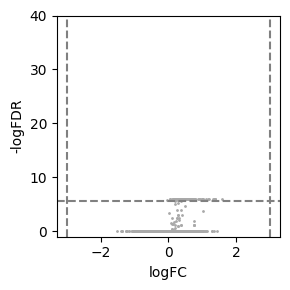

In [14]:
df = res
df['logFC'] = df['log2FoldChange']
df['adj.P.Val'] = df['padj']

FC = 3
    
plt.figure(figsize=(3, 3))
plt.scatter(x=df['logFC'],y=df['adj.P.Val'].apply(lambda x:-np.log10(x+.000001)),s=1,label="Not significant", color = 'darkgrey')

# highlight down- or up- regulated genes
down = df[(df['logFC']<=-FC)&(df['adj.P.Val']<=0.05)]
up = df[(df['logFC']>=FC)&(df['adj.P.Val']<=0.05)]


plt.scatter(x=down['logFC'],y=down['adj.P.Val'].apply(lambda x:-np.log10(x+1e-32)),s=3,label="Down-regulated",color="red")
plt.scatter(x=up['logFC'],y=up['adj.P.Val'].apply(lambda x:-np.log10(x+1e-30)),s=3,label="Up-regulated",color="red")
texts=[]
for i,r in up.iterrows():
    texts.append(plt.text(x=r['logFC'],y=-np.log10(r['adj.P.Val']),s=i))
for i,r in down.iterrows():
    texts.append(plt.text(x=r['logFC']+2,y=-np.log10(r['adj.P.Val']+1e-30),s=i, va='bottom', ha='left'))
plt.xlabel("logFC")
plt.ylabel("-logFDR")
plt.axvline(-FC,color="grey",linestyle="--")
plt.axvline(FC,color="grey",linestyle="--")
plt.axhline(-np.log10(.05/df.shape[0]),color="grey",linestyle="--")
#adjust_text(texts,arrowprops=dict(arrowstyle="-", color='black', lw=0.5), expand = (1.5, 1.5))
plt.ylim([-1, 40])
plt.tight_layout()
#plt.savefig('figures_final/fig_3b.png')
plt.show()



# Correlation of Differentially "Expressed" Virus to genes

## Subset to specific Virus

In [ ]:
vir = 'u234187'

small_vir_adata = virus_adata[:,virus_adata.var.rep_ID == vir]
small_nid_vir_adata = sum_by(small_vir_adata, 'nid')
small_nid_vir_adata.obs = pd.merge(small_nid_vir_adata.obs.reset_index(names='nid'), small_vir_adata.obs.groupby('nid', observed=True).first()[['sex', 'time', 'lifetime']].reset_index())
small_nid_vir_adata

In [ ]:
small_rat_adata = rat_adata.copy()
small_rat_adata = small_rat_adata[~small_rat_adata.obs.tissue.isin(['VENACV', 'ADRNL','TESTES', 'OVARY'])]
small_nid_rat_adata = sum_by(small_rat_adata, 'nid')
small_nid_rat_adata.obs = pd.merge(small_nid_rat_adata.obs.reset_index(names='nid'), small_rat_adata.obs.groupby('nid', observed=True).first()[['sex', 'time', 'calculated.variables.vo2_max_change']].reset_index())
small_nid_rat_adata

In [ ]:
count_data = pd.DataFrame(small_nid_rat_adata.X,
            columns = small_nid_rat_adata.var.gene_id)

vir_counts = pd.DataFrame({
    'vir_counts' : small_nid_vir_adata.X.toarray().transpose().tolist()[0]
})

vir_correlations = count_data.corrwith(vir_counts['vir_counts'])
rat_analysis_df = pd.DataFrame({
    'vir_corr' : vir_correlations.values,
    'gene_counts' : count_data.sum(),
    'gene_name' : small_nid_rat_adata.var.X3
})
rat_analysis_df = rat_analysis_df[~rat_analysis_df['vir_corr'].isna()]
rat_analysis_df.head()

## Calculate p-value and adjust for multiple hypothesis testing

In [ ]:
rat_analysis_df['p_val'] = rat_analysis_df.vir_corr.apply(lambda x: 2*scipy.stats.beta(small_nid_rat_adata.shape[0]/2 -1, small_nid_rat_adata.shape[0]/2 -1, loc=-1, scale=2).cdf(-abs(x)))
rat_analysis_df['p_val_adj'] = statsmodels.stats.multitest.multipletests(rat_analysis_df['p_val'],
                                          method='bonferroni')[1]
print(rat_analysis_df.shape)
rat_analysis_df.sort_values(['p_val'], ascending=True).iloc[0:10,:]

## Subset for genes both significantly correlated with virus and found to be significant in the original analysis

In [ ]:
filtered_df = rat_analysis_df[rat_analysis_df.p_val_adj < .05]
print(filtered_df.shape)
filtered_df_old = filtered_df[genes_in_original(filtered_df.index.values,og_supp_table =2)]
print(filtered_df_old.shape)
filtered_df_old.sort_values(['p_val'], ascending=True).iloc[0:10,:]

### Plot Gene of interest versus virus

In [ ]:
gene = filtered_df_old.sort_values(['p_val'], ascending=True).index[0]
gene

In [ ]:
comp_df = pd.DataFrame({
    gene : small_nid_rat_adata[:,small_nid_rat_adata.var.index == gene].X.transpose().tolist()[0],
    vir : small_nid_vir_adata[:,small_nid_vir_adata.var.rep_ID == vir].X.toarray().transpose().tolist()[0],
    'nid' : small_nid_rat_adata.obs.nid.values,
    'vir_nid' : small_nid_vir_adata.obs.nid.values,
    'sex' : small_nid_rat_adata.obs.sex.values,
    'time' : small_nid_rat_adata.obs.time.values,
    'vo2_max' : small_nid_rat_adata.obs['calculated.variables.vo2_max_change'].values
})

In [ ]:
plt.figure(figsize=(3, 3))
sns.scatterplot(comp_df, x = gene, y = vir)
sns.scatterplot(comp_df[comp_df.nid == 'F0K'], x = gene, y = vir, color = 'red')
texts=[]
name_df = comp_df[comp_df.nid == 'F0K'].set_index('nid')
for i,r in name_df.iterrows():
    texts.append(plt.text(x=r[gene]-25,y=r[vir]-30,s=i))
adjust_text(texts,arrowprops=dict(arrowstyle="-", color='black', lw=0.5))
plt.xlim([0, 350])
plt.xlabel('Tigit (Gene Reported as \n Differentially Expressed in Lung)')
plt.tight_layout()
plt.savefig('figures_final/fig_3d.png')
plt.show()

### Change in V02 Max of time 0 individuals

In [ ]:
plt.figure(figsize=(1.5, 5))
small_df = comp_df[comp_df.time.isin(['0'])].set_index('nid')
small_df['time'] = small_df.time.cat.remove_unused_categories()
ax = sns.scatterplot(small_df, x = 'time', y = 'vo2_max', alpha=1)
ax = sns.scatterplot(small_df[small_df.index == 'F0K'], x = 'time', y = 'vo2_max', color = 'red', alpha=1)
texts = []
red_texts = []
for i,r in small_df.iterrows():
    if i == 'F0K': 
        red_texts.append(plt.text(x=r['time'],y=r['vo2_max'],s=i, ha = 'right', va = 'bottom'))
    else:
        texts.append(plt.text(x=r['time'],y=r['vo2_max'],s=i, ha = 'right', va = 'bottom'))
adjust_text(texts,arrowprops=dict(arrowstyle="-", color='black', lw=0.5), expand = (1.85, 1))
adjust_text(red_texts,arrowprops=dict(arrowstyle="-", color='red', lw=0.5), expand = (1.85, 1))
plt.title('Change in \n VO$_2$ max')
plt.ylabel(None)
ax.yaxis.tick_right()
#ax.yaxis.set_label_position('right')
plt.tight_layout()
plt.savefig('figures_final/fig_3e.png')
plt.show()

## Plot Expression of Virus of Interest across tissues

In [ ]:
filtered_res = res[res.padj < .05]
virus_adata.obs['F0K Virus Counts'] = virus_adata.obs.tissue
sc.pl._utils._set_colors_for_categorical_obs(virus_adata, 'F0K Virus Counts', palette = color_dict)
sc.set_figure_params(figsize=(2, 8.5))
hmp = sc.pl.heatmap(virus_adata[virus_adata.obs.nid == 'F0K'], 'u234187', groupby = 'F0K Virus Counts', log=False, 
                    use_raw = False, swap_axes = True,
             show = False)
ax = hmp["groupby_ax"]
ax.set_xticklabels(ax.get_xticklabels(), rotation = 45, ha = 'right')
ax.figure.savefig('figures_final/fig_3c.png', bbox_inches = "tight")

# View Expression of Tigit

In [ ]:
rat_adata = anndata.read_h5ad("../omics_data/rat_RNA_meta.h5ad")
rat_adata

In [ ]:
sc.pl.heatmap(rat_adata[rat_adata.obs.tissue == 'LUNG'], 
              'ENSRNOG00000056574', groupby='nid', log=True, 
                    use_raw = False, swap_axes = True,
             show = False)